In [27]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
!pip install -U bitsandbytes>=0.46.1 -q


In [29]:
!pip install bitsandbytes

In [30]:
import os
import re
import random
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, GroupShuffleSplit

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from datasets import load_dataset, Dataset
from huggingface_hub import login

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

In [31]:
# ── Global Configuration ───────────────────────────────────────────────────────

SEED           = 42
MODEL_NAME     = "mistralai/Mistral-7B-v0.1"   # fallback: "meta-llama/Llama-3.2-3B"
STRATEGY       = "zero_shot"                    # "zero_shot" | "chain_of_thought" | "factuality_aware"
N_SAMPLES      = 3000                           # 1500 hallucinated + 1500 correct

LAYERS_TO_KEEP = [4, 8, 16, 20, 24, 28, 32]   # early / mid / late sweep
POSITIONS      = ["last_prompt", "last_gen", "mean_gen"]
TOKEN_F1_THR   = 0.3                            # label-noise filter threshold

DATA_DIR       = "data"
CACHE_DIR = "/content/drive/MyDrive/HALLUPROBE/cache"

RESULTS_DIR    = "results"
BATCH_SIZE = 16  # reduce to 4-8 if OOM

FORCE_EXTRACT  = False                        # re-extract even if cache exists

# Prompt templates (kept here so nothing is hardcoded downstream)
PROMPT_TEMPLATES = {
    "zero_shot": "Answer the following question: {question}",
    "chain_of_thought": (
        "Question: {question}\n"
        "Let's think step by step.\n"
        "Final Answer:"
    ),
    "factuality_aware": (
        "Answer the following question based only on facts you are certain about. "
        "If you are not sure, say I don't know.\n"
        "Question: {question}\nAnswer:"
    ),
}

# Delimiter used to extract the answer portion from CoT output
COT_ANSWER_DELIMITER = "Final Answer:"

# ── Reproducibility ────────────────────────────────────────────────────────────

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Directory setup ────────────────────────────────────────────────────────────

os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(CACHE_DIR,   exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Device : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"Model  : {MODEL_NAME}")
print(f"Strategy: {STRATEGY}")

Device : NVIDIA A100-SXM4-80GB
Model  : mistralai/Mistral-7B-v0.1
Strategy: zero_shot


In [32]:
pd.set_option("display.max_colwidth", 120)

# ── 1. HaluEval-QA (primary) ──────────────────────────────────────────────────
print("=" * 60)
print("HaluEval-QA")
print("=" * 60)

halueval_raw = load_dataset("pminervini/HaluEval", "qa_samples", cache_dir=DATA_DIR)
print(halueval_raw)

df_halu = halueval_raw["data"].to_pandas()
print(f"\nColumns : {df_halu.columns.tolist()}")
print(f"Shape   : {df_halu.shape}")
print(f"Nulls   :\n{df_halu.isnull().sum()}")
print(f"\nDtypes  :\n{df_halu.dtypes}")
display(df_halu.head(3))


# ── 2. TriviaQA (OOD validation) ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("TriviaQA — rc.wikipedia")
print("=" * 60)

triviaqa_raw = load_dataset("mandarjoshi/trivia_qa", "rc.wikipedia", cache_dir=DATA_DIR)
print(triviaqa_raw)

df_trivia = triviaqa_raw["train"].to_pandas()
print(f"\nColumns : {df_trivia.columns.tolist()}")
print(f"Shape   : {df_trivia.shape}")
print(f"Nulls   :\n{df_trivia.isnull().sum()}")
print(f"\nDtypes  :\n{df_trivia.dtypes}")
display(df_trivia.head(3))


HaluEval-QA
DatasetDict({
    data: Dataset({
        features: ['knowledge', 'question', 'answer', 'hallucination'],
        num_rows: 10000
    })
})

Columns : ['knowledge', 'question', 'answer', 'hallucination']
Shape   : (10000, 4)
Nulls   :
knowledge        0
question         0
answer           0
hallucination    0
dtype: int64

Dtypes  :
knowledge        object
question         object
answer           object
hallucination    object
dtype: object


,knowledge,question,answer,hallucination
0,Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th century.Firs...,Which magazine was started first Arthur's Magazine or First for Women?,First for Women was started first.,yes
1,"The Oberoi family is an Indian family that is famous for its involvement in hotels, namely through The Oberoi Group....",The Oberoi family is part of a hotel company that has a head office in what city?,Delhi,no
2,"Allison Beth ""Allie"" Goertz (born March 2, 1991) is an American musician. Goertz is known for her satirical songs ba...","Musician and satirist Allie Goertz wrote a song about the ""The Simpsons"" character Milhouse, who Matt Groening named...",President Richard Nixon,no



TriviaQA — rc.wikipedia


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'question_id', 'question_source', 'entity_pages', 'search_results', 'answer'],
        num_rows: 61888
    })
    validation: Dataset({
        features: ['question', 'question_id', 'question_source', 'entity_pages', 'search_results', 'answer'],
        num_rows: 7993
    })
    test: Dataset({
        features: ['question', 'question_id', 'question_source', 'entity_pages', 'search_results', 'answer'],
        num_rows: 7701
    })
})

Columns : ['question', 'question_id', 'question_source', 'entity_pages', 'search_results', 'answer']
Shape   : (61888, 6)
Nulls   :
question           0
question_id        0
question_source    0
entity_pages       0
search_results     0
answer             0
dtype: int64

Dtypes  :
question           object
question_id        object
question_source    object
entity_pages       object
search_results     object
answer             object
dtype: object


,question,question_id,question_source,entity_pages,search_results,answer
0,Where in England was Dame Judi Dench born?,tc_3,http://www.triviacountry.com/,"{'doc_source': ['TagMe', 'TagMe'], 'filename': ['England.txt', 'Judi_Dench.txt'], 'title': ['England', 'Judi Dench']...","{'description': [], 'filename': [], 'rank': [], 'title': [], 'url': [], 'search_context': []}","{'aliases': ['Park Grove (1895)', 'York UA', 'Yorkish', 'UN/LOCODE:GBYRK', 'York, UK', 'Eoforwic', 'Park Grove Schoo..."
1,From which country did Angola achieve independence in 1975?,tc_8,http://www.triviacountry.com/,"{'doc_source': ['TagMe', 'TagMe', 'Search'], 'filename': ['Nation_state.txt', 'Angola.txt', 'Angolan_Civil_War.txt']...","{'description': [], 'filename': [], 'rank': [], 'title': [], 'url': [], 'search_context': []}","{'aliases': ['Portogało', 'Republic of Portugal', 'PORTUGAL', 'Portekiz', 'Portugallu', 'O Papagaio', 'ISO 3166-1:PT..."
2,Which city does David Soul come from?,tc_9,http://www.triviacountry.com/,"{'doc_source': ['TagMe'], 'filename': ['David_Soul.txt'], 'title': ['David Soul'], 'wiki_context': ['David Soul (bor...","{'description': [], 'filename': [], 'rank': [], 'title': [], 'url': [], 'search_context': []}","{'aliases': ['Chi-Beria', 'Sayre language academy', 'Chicago', 'Chicago, Illinois', 'Hog Butcher for the World', 'La..."


In [33]:
from collections import Counter

# ── Text normalization (proposal §3.5: lower-case, strip punctuation & articles) ──

def normalize_answer(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    return " ".join(text.split())


def token_f1(prediction: str, gold: str) -> float:
    pred_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    n_common = sum(common.values())
    if n_common == 0:
        return 0.0
    precision = n_common / len(pred_tokens)
    recall    = n_common / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)


def exact_match(prediction: str, gold: str) -> bool:
    return normalize_answer(prediction) == normalize_answer(gold)

In [34]:
def preprocess_halueval(
    raw,
    n_samples: int = N_SAMPLES,
    seed:      int = SEED,
) -> pd.DataFrame:
    df = raw["data"].to_pandas()

    # Gold answers are the rows where the answer is NOT hallucinated
    df_gold = (
        df[df["hallucination"] == "no"][["question", "knowledge", "answer"]]
        .rename(columns={"answer": "gold_answer"})
        .drop_duplicates(subset="question")
        .reset_index(drop=True)
    )

    df_gold = df_gold.sample(
        n=min(n_samples, len(df_gold)), random_state=seed
    ).reset_index(drop=True)

    df_gold["question_id"] = df_gold.index

    print(f"HaluEval  — {len(df_gold)} unique questions retained")
    return df_gold


def preprocess_triviaqa(
    raw,
    n_samples: int = N_SAMPLES,
    seed:      int = SEED,
) -> pd.DataFrame:
    df = raw["train"].to_pandas()

    # Unpack nested answer dict
    df["gold_answer"]   = df["answer"].apply(lambda a: a["value"])
    df["gold_aliases"]  = df["answer"].apply(lambda a: a["normalized_aliases"])

    df = (
        df[["question", "gold_answer", "gold_aliases"]]
        .drop_duplicates(subset="question")
        .reset_index(drop=True)
    )

    df = df.sample(
        n=min(n_samples, len(df)), random_state=seed
    ).reset_index(drop=True)

    df["question_id"] = df.index

    print(f"TriviaQA  — {len(df)} unique questions retained")
    return df


# ── Run ────────────────────────────────────────────────────────────────────────

df_halu   = preprocess_halueval(halueval_raw)
df_trivia = preprocess_triviaqa(triviaqa_raw)

display(df_halu.head(3))
display(df_trivia.head(3))


HaluEval  — 3000 unique questions retained
TriviaQA  — 3000 unique questions retained


,question,knowledge,gold_answer,question_id
0,Bret Schundler served in the cabinet of a New Jersey governor whose term ended in what year?,He served in the Cabinet of Governor Chris Christie as New Jersey Commissioner of Education until he was dismissed ...,2018,0
1,The Government Accountability Institute (GAI) is a conservative nonprofit investigative research organization locate...,"The group is known for its involvement with the publication of the investigative books ""Clinton Cash: The Untold St...",2015,1
2,"How many people died in the downing of the flight investigated by Eliot Higgins, the British citizen journalist and ...","Eliot Higgins (born 1979), who previously used the pseudonym Brown Moses, is a British citizen journalist and blogge...",283 passengers and 15 crew,2


,question,gold_answer,gold_aliases,question_id
0,"'Proud Mary', 'Bad Moon Rising', 'Green River' were all in the UK charts in 1969, who released them?",'CREEDANCE CLEARWATER REVIVAL',"[creedance clearwater revival, creedance clearwater, stu alden cook, credance clearwater revival, stuart alden cook,...",0
1,What is the generic name for all of the greater festivals of the Christian Church?,Sacraments,"[sacrament latter day saint, christian sacraments, sacrament, sacrament mormonism, sacraments, sacrament christianit...",1
2,Which folk-hero was the subject of Rossini's final opera?,WILLIAM TELL,"[affair to forget will grace, he shoots they snore, young tactless, fear clothing, alice doesn t lisp here anymore, ...",2


In [35]:
from sklearn.utils.class_weight import compute_sample_weight

def train_lr_probe(X_train: np.ndarray, y_train:np.ndarray):
    "Logistic Reression Probe"
    scaler= StandardScaler()
    X = scaler.fit_transform(X_train)
    model = LogisticRegression(
        class_weight = "balanced",
        max_iter = 1000,
        random_state = SEED,
    )
    model.fit(X, y_train)
    return model, scaler

def train_svm_probe(X_train: np.ndarray,y_train: np.ndarray):
    "SVM Probe"
    scaler= StandardScaler()
    X= scaler.fit_transform(X_train)
    model= LinearSVC(
        class_weight = "balanced",
        max_iter = 2000,
        random_state = SEED,
    )
    model.fit(X, y_train)
    return model, scaler

def train_mlp_probe(X_train: np.ndarray, y_train: np.ndarray):
    "MLP Probe"
    scaler = StandardScaler()
    X= scaler.fit_transform(X_train)
    sample_weights = compute_sample_weight("balanced", y_train)
    model = MLPClassifier(
        hidden_layer_sizes= (256,128,64),
        activation = "relu",
        max_iter = 200,
        random_state = SEED,
        early_stopping= True

    )
    model.fit(X, y_train)
    return model, scaler


In [36]:
def extract_last_prompt(hidden_states, b, padded_prompt_len, layers=LAYERS_TO_KEEP):
    result = {}
    for l in layers:
        result[l] = hidden_states[l][b, padded_prompt_len - 1, :].cpu().float().numpy()
    return result


def extract_last_gen(hidden_states, b, padded_prompt_len, actual_gen_len, layers=LAYERS_TO_KEEP):
    last_gen_pos = padded_prompt_len + actual_gen_len - 1
    result = {}
    for l in layers:
        result[l] = hidden_states[l][b, last_gen_pos, :].cpu().float().numpy()
    return result


def extract_mean_gen(hidden_states, b, padded_prompt_len, actual_gen_len, layers=LAYERS_TO_KEEP):
    result = {}
    for l in layers:
        gen_hs = hidden_states[l][b, padded_prompt_len : padded_prompt_len + actual_gen_len, :]
        result[l] = gen_hs.mean(dim=0).cpu().float().numpy()
    return result


def extract_hidden_states(extraction_type, hidden_states, b, padded_prompt_len, actual_gen_len, layers=LAYERS_TO_KEEP):
    if extraction_type == "last_prompt":
        return extract_last_prompt(hidden_states, b, padded_prompt_len, layers)
    elif extraction_type == "last_gen":
        return extract_last_gen(hidden_states, b, padded_prompt_len, actual_gen_len, layers)
    elif extraction_type == "mean_gen":
        return extract_mean_gen(hidden_states, b, padded_prompt_len, actual_gen_len, layers)
    else:
        raise ValueError(f"Unknown position '{extraction_type}'. Expected one of {POSITIONS}")


In [37]:
import pickle

def extract_answer_for_matching(generated_text: str, strategy: str) -> str:
    """For CoT, return only the text after 'Final Answer:' for label matching.
    Falls back to the full generated text if the delimiter is absent."""
    if strategy == "chain_of_thought":
        delimiter = COT_ANSWER_DELIMITER
        idx = generated_text.find(delimiter)
        if idx != -1:
            return generated_text[idx + len(delimiter):].strip()
    return generated_text

def answer_match(generated, gold, aliases):
    gen_norm = normalize_answer(generated)
    if normalize_answer(gold) in gen_norm:
        return True
    for alias in aliases:
        if normalize_answer(alias) in gen_norm:
            return True
    return False

def load_model(model_name=MODEL_NAME, quantize=True):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token

    if quantize and torch.cuda.is_available():
        quant_config = BitsAndBytesConfig(
            load_in_4bit              = True,
            bnb_4bit_compute_dtype    = torch.float16,
            bnb_4bit_use_double_quant = True,
            bnb_4bit_quant_type       = "nf4",
        )
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config = quant_config,
            device_map          = "auto",
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype = torch.float16,
            device_map  = "auto",
        )

    model.eval()
    print(f"Loaded {model_name} | quantized={quantize} | device={model.device}")
    return model, tokenizer

# ── Cache Helpers ───────────────────────────────────────────────────────────────

def get_cache_path(strategy, dataset_tag="halueval"):
    safe_model = MODEL_NAME.replace("/", "_")
    filename = f"{safe_model}_{dataset_tag}_{strategy}.pkl"
    return os.path.join(CACHE_DIR, filename)

def save_activations(records, strategy):
    path = get_cache_path(strategy)
    with open(path, "wb") as f:
        pickle.dump(records, f)
    print(f"Saved {len(records)} records to {path}")


def load_activations(strategy):
    path = get_cache_path(strategy)
    with open(path, "rb") as f:
        records = pickle.load(f)
    print(f"Loaded {len(records)} records from {path}")
    return records

@torch.no_grad()
def inference_extract(model, tokenizer, df, strategy, max_new_tokens=32, batch_size=BATCH_SIZE):
    cache_path = get_cache_path(strategy)
    if not FORCE_EXTRACT and os.path.exists(cache_path):
        return load_activations(strategy)

    tokenizer.padding_side = "left"
    records  = []
    all_rows = [row for _, row in df.iterrows()]

    for start in tqdm(range(0, len(all_rows), batch_size), desc=f"Extracting [{strategy}]"):
        batch_rows     = all_rows[start : start + batch_size]
        cur_batch_size = len(batch_rows)
        prompts        = [PROMPT_TEMPLATES[strategy].format(question=row["question"]) for row in batch_rows]

        inputs            = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)
        padded_prompt_len = inputs["input_ids"].shape[1]

        gen_out = model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            do_sample      = False,
            pad_token_id   = tokenizer.eos_token_id,
            output_scores  = True,
            return_dict_in_generate = True,
        )
        gen_ids = gen_out.sequences
        scores_tensor = torch.stack(gen_out.scores, dim=0).float()  # (gen_len, batch, vocab)

        gen_attention_mask = torch.cat([
            inputs["attention_mask"],
            torch.ones(cur_batch_size, max_new_tokens, dtype=torch.long, device=model.device),
        ], dim=1)

        outputs = model(gen_ids, attention_mask=gen_attention_mask, output_hidden_states=True)

        for b, row in enumerate(batch_rows):
            gen_part      = gen_ids[b, padded_prompt_len:]
            eos_positions = (gen_part == tokenizer.eos_token_id).nonzero(as_tuple=True)[0]
            actual_gen_len = eos_positions[0].item() + 1 if len(eos_positions) > 0 else max_new_tokens

            hidden_states_by_position = {}
            for position in POSITIONS:
                hidden_states_by_position[position] = extract_hidden_states(
                    position, outputs.hidden_states, b, padded_prompt_len, actual_gen_len
                )

            generated_text = tokenizer.decode(gen_ids[b, padded_prompt_len:], skip_special_tokens=True)

            # For CoT, match only the text after "Final Answer:" to avoid
            # the reasoning trace polluting the label (e.g. negations of the gold answer)
            match_text   = extract_answer_for_matching(generated_text, strategy)
            gold_aliases = row.get("gold_aliases", [])
            label = 0 if answer_match(match_text, row["gold_answer"], gold_aliases) else 1

            # ── Output-space baseline features ────────────────────────────
            gen_scores = scores_tensor[:actual_gen_len, b, :]        # (actual_gen_len, vocab)
            log_probs  = torch.log_softmax(gen_scores, dim=-1)
            gen_tok_ids = gen_ids[b, padded_prompt_len : padded_prompt_len + actual_gen_len]
            tok_log_probs = log_probs[torch.arange(actual_gen_len), gen_tok_ids]  # (actual_gen_len,)
            mean_log_prob = tok_log_probs.mean().item()
            min_log_prob  = tok_log_probs.min().item()
            perplexity    = torch.exp(-tok_log_probs.mean()).item()
            probs         = torch.softmax(gen_scores, dim=-1)
            token_entropy = (-probs * torch.log(probs + 1e-10)).sum(dim=-1)
            mean_entropy  = token_entropy.mean().item()

            records.append({
                "question_id"    : row["question_id"],
                "question"       : row["question"],
                "generated_text" : generated_text,
                "match_text"     : match_text,
                "gold_answer"    : row["gold_answer"],
                "label"          : label,
                "hidden_states"  : hidden_states_by_position,
                "mean_log_prob"  : mean_log_prob,
                "min_log_prob"   : min_log_prob,
                "perplexity"     : perplexity,
                "mean_entropy"   : mean_entropy,
            })

        del outputs, gen_ids, gen_out, scores_tensor, inputs, gen_attention_mask

    save_activations(records, strategy)
    return records

In [38]:
def build_feature_matrix(records, position, layer):
    X      = []
    y      = []
    groups = []

    for record in records:
        X.append(record["hidden_states"][position][layer])
        y.append(record["label"])
        groups.append(record["question_id"])

    X      = np.array(X)       # (n_samples, hidden_dim)
    y      = np.array(y)       # (n_samples,)
    groups = np.array(groups)  # (n_samples,) — one group id per question

    return X, y, groups


def group_aware_split(X, y, groups, seed=SEED):
    # 80 / 10 / 10 split at question level
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=seed)
    dev_idx, test_idx = next(gss_test.split(X, groups=groups))

    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.10 / 0.90, random_state=seed)
    train_idx, val_idx = next(gss_val.split(X[dev_idx], groups=groups[dev_idx]))

    train_idx = dev_idx[train_idx]
    val_idx   = dev_idx[val_idx]

    X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
    y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

    print(f"Split → train: {len(X_train)} | val: {len(X_val)} | test: {len(X_test)}")

    return X_train, X_val, X_test, y_train, y_val, y_test


In [39]:
# ── 1. Unified score getter ────────────────────────────────────────────────────

def get_scores(model, X):
    if isinstance(model, LinearSVC):
        return model.decision_function(X)
    return model.predict_proba(X)[:, 1]


# ── 2. Probe evaluator ─────────────────────────────────────────────────────────

def evaluate_probe(model, scaler, X, y):
    X_scaled = scaler.transform(X)
    scores   = get_scores(model, X_scaled)
    preds    = model.predict(X_scaled)

    return {
        "auroc"     : roc_auc_score(y, scores),
        "f1_macro"  : f1_score(y, preds, average="macro"),
        "f1_hall"   : f1_score(y, preds, pos_label=1),
        "f1_correct": f1_score(y, preds, pos_label=0),
        "precision" : precision_score(y, preds),
        "recall"    : recall_score(y, preds),
        "accuracy"  : accuracy_score(y, preds),
    }


# ── 3. Training loop ───────────────────────────────────────────────────────────

def run_training_loop(records_by_strategy):
    probe_fns = {
        "lr" : train_lr_probe,
        "svm": train_svm_probe,
        "mlp": train_mlp_probe,
    }

    results = []

    for strategy, records in records_by_strategy.items():
        for position in POSITIONS:
            for layer in LAYERS_TO_KEEP:
                X, y, groups = build_feature_matrix(records, position, layer)
                X_train, X_val, X_test, y_train, y_val, y_test = group_aware_split(X, y, groups)

                for probe_name, probe_fn in probe_fns.items():
                    model, scaler    = probe_fn(X_train, y_train)
                    val_metrics      = evaluate_probe(model, scaler, X_val,  y_val)
                    test_metrics     = evaluate_probe(model, scaler, X_test, y_test)

                    results.append({
                        "strategy" : strategy,
                        "position" : position,
                        "layer"    : layer,
                        "probe"    : probe_name,
                        "model"    : model,
                        "scaler"   : scaler,
                        "val"      : val_metrics,
                        "test"     : test_metrics,
                    })

                    print(
                        f"{strategy:20s} | {position:12s} | L{layer:2d} | {probe_name:3s} | "
                        f"val AUROC={val_metrics['auroc']:.3f} | "
                        f"test AUROC={test_metrics['auroc']:.3f}"
                    )

    return results


In [40]:
# ── 1. Ablation Heatmap ────────────────────────────────────────────────────────

def plot_heatmap(results, strategy, probe, split="test"):
    filtered = [
        r for r in results
        if r["strategy"] == strategy and r["probe"] == probe
    ]

    rows = []
    for r in filtered:
        rows.append({
            "layer"   : r["layer"],
            "position": r["position"],
            "auroc"   : r[split]["auroc"],
        })

    pivot = pd.DataFrame(rows).pivot(
        index="layer", columns="position", values="auroc"
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", vmin=0.5, vmax=1.0)
    plt.title(f"AUROC Heatmap — {strategy} | {probe} | {split}")
    plt.tight_layout()
    plt.show()


# ── 2. OOD Evaluation (TriviaQA) ──────────────────────────────────────────────

def run_ood_evaluation(results, ood_records):
    ood_results = []

    for r in results:
        X_ood, y_ood, _ = build_feature_matrix(
            ood_records, r["position"], r["layer"]
        )
        metrics = evaluate_probe(r["model"], r["scaler"], X_ood, y_ood)

        ood_results.append({
            "strategy" : r["strategy"],
            "position" : r["position"],
            "layer"    : r["layer"],
            "probe"    : r["probe"],
            "ood"      : metrics,
        })

        print(
            f"{r['strategy']:20s} | {r['position']:12s} | L{r['layer']:2d} | "
            f"{r['probe']:3s} | OOD AUROC={metrics['auroc']:.3f}"
        )

    return ood_results


# ── 3. Failure Analysis ────────────────────────────────────────────────────────

def failure_analysis(result, records, n_each=15, split="test"):
    X, y, groups = build_feature_matrix(
        records, result["position"], result["layer"]
    )
    _, _, X_test, _, _, y_test = group_aware_split(X, y, groups)
    _, _, idx_test, _, _, _    = group_aware_split(
        np.arange(len(X)), y, groups
    )

    X_scaled = result["scaler"].transform(X_test)
    preds    = result["model"].predict(X_scaled)

    fp_idx = np.where((preds == 1) & (y_test == 0))[0][:n_each]
    fn_idx = np.where((preds == 0) & (y_test == 1))[0][:n_each]

    def show(indices, label):
        print(f"\n── {label} ({len(indices)}) ────────────────────────────")
        for i in indices:
            rec = records[idx_test[i]]
            print(f"  Q : {rec['question']}")
            print(f"  Gold      : {rec['gold_answer']}")
            print(f"  Generated : {rec['generated_text']}")
            print()

    show(fp_idx, "False Positives (predicted hallucinated, actually correct)")
    show(fn_idx, "False Negatives (predicted correct, actually hallucinated)")


In [41]:
# ── Pre-run diagnostics — run this before the zero-shot cell ──────────────────
print(f"CACHE_DIR     : {CACHE_DIR}")
print(f"FORCE_EXTRACT : {FORCE_EXTRACT}")
print()

for strategy in ["zero_shot", "factuality_aware", "chain_of_thought"]:
    path = get_cache_path(strategy)
    exists = os.path.exists(path)
    would_extract = FORCE_EXTRACT or not exists
    print(f"  {strategy:20s} | path={path}")
    print(f"  {'':20s} | exists={exists} | would_extract={would_extract}")
    print()

assert not FORCE_EXTRACT, "FORCE_EXTRACT is True — zero_shot will re-extract!"
print("All checks passed — zero_shot and factuality_aware will load from cache.")

CACHE_DIR     : /content/drive/MyDrive/HALLUPROBE/cache
FORCE_EXTRACT : False

  zero_shot            | path=/content/drive/MyDrive/HALLUPROBE/cache/mistralai_Mistral-7B-v0.1_halueval_zero_shot.pkl
                       | exists=True | would_extract=False

  factuality_aware     | path=/content/drive/MyDrive/HALLUPROBE/cache/mistralai_Mistral-7B-v0.1_halueval_factuality_aware.pkl
                       | exists=True | would_extract=False

  chain_of_thought     | path=/content/drive/MyDrive/HALLUPROBE/cache/mistralai_Mistral-7B-v0.1_halueval_chain_of_thought.pkl
                       | exists=True | would_extract=False

All checks passed — zero_shot and factuality_aware will load from cache.


In [42]:
# ── Sanity Check — Zero Shot Full Pipeline ─────────────────────────────────────

# 1. Load model
model, tokenizer = load_model()

# 2. Extract hidden states for zero_shot
records_zero_shot = inference_extract(model, tokenizer, df_halu, "zero_shot")
print(f"\nExtracted {len(records_zero_shot)} records")
print(f"Label balance — correct: {sum(r['label']==0 for r in records_zero_shot)} | "
      f"hallucinated: {sum(r['label']==1 for r in records_zero_shot)}")
print(f"Sample generated text : {records_zero_shot[0]['generated_text']}")
print(f"Sample gold answer    : {records_zero_shot[0]['gold_answer']}")
print(f"Sample label          : {records_zero_shot[0]['label']}")

# 3. Train and evaluate all probes across all (layer x position)
results = run_training_loop({"zero_shot": records_zero_shot})

# 4. Summary table
rows = []
for r in results:
    row = {
        "position" : r["position"],
        "layer"    : r["layer"],
        "probe"    : r["probe"],
    }
    row.update({f"val_{k}": v for k, v in r["val"].items()})
    row.update({f"test_{k}": v for k, v in r["test"].items()})
    rows.append(row)




Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loaded mistralai/Mistral-7B-v0.1 | quantized=True | device=cuda:0
Loaded 3000 records from /content/drive/MyDrive/HALLUPROBE/cache/mistralai_Mistral-7B-v0.1_halueval_zero_shot.pkl

Extracted 3000 records
Label balance — correct: 894 | hallucinated: 2106
Sample generated text : 

The answer is 2002.

Schundler, a former New Jersey state senator, was the state’s secretary of
Sample gold answer    : 2018
Sample label          : 1
Split → train: 2400 | val: 300 | test: 300
zero_shot            | last_prompt  | L 4 | lr  | val AUROC=0.634 | test AUROC=0.682


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


zero_shot            | last_prompt  | L 4 | svm | val AUROC=0.609 | test AUROC=0.657
zero_shot            | last_prompt  | L 4 | mlp | val AUROC=0.781 | test AUROC=0.728
Split → train: 2400 | val: 300 | test: 300
zero_shot            | last_prompt  | L 8 | lr  | val AUROC=0.663 | test AUROC=0.726
zero_shot            | last_prompt  | L 8 | svm | val AUROC=0.623 | test AUROC=0.703
zero_shot            | last_prompt  | L 8 | mlp | val AUROC=0.777 | test AUROC=0.793
Split → train: 2400 | val: 300 | test: 300
zero_shot            | last_prompt  | L16 | lr  | val AUROC=0.717 | test AUROC=0.726
zero_shot            | last_prompt  | L16 | svm | val AUROC=0.679 | test AUROC=0.707
zero_shot            | last_prompt  | L16 | mlp | val AUROC=0.795 | test AUROC=0.774
Split → train: 2400 | val: 300 | test: 300
zero_shot            | last_prompt  | L20 | lr  | val AUROC=0.736 | test AUROC=0.750
zero_shot            | last_prompt  | L20 | svm | val AUROC=0.713 | test AUROC=0.736
zero_shot            

...

zero_shot            | last_gen     | L24 | svm | val AUROC=0.627 | test AUROC=0.592
zero_shot            | last_gen     | L24 | mlp | val AUROC=0.647 | test AUROC=0.627
Split → train: 2400 | val: 300 | test: 300
zero_shot            | last_gen     | L28 | lr  | val AUROC=0.590 | test AUROC=0.633


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


zero_shot            | last_gen     | L28 | svm | val AUROC=0.576 | test AUROC=0.614
zero_shot            | last_gen     | L28 | mlp | val AUROC=0.629 | test AUROC=0.628
Split → train: 2400 | val: 300 | test: 300
zero_shot            | last_gen     | L32 | lr  | val AUROC=0.604 | test AUROC=0.673


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


zero_shot            | last_gen     | L32 | svm | val AUROC=0.573 | test AUROC=0.652
zero_shot            | last_gen     | L32 | mlp | val AUROC=0.633 | test AUROC=0.643
Split → train: 2400 | val: 300 | test: 300
zero_shot            | mean_gen     | L 4 | lr  | val AUROC=0.731 | test AUROC=0.719
zero_shot            | mean_gen     | L 4 | svm | val AUROC=0.699 | test AUROC=0.677
zero_shot            | mean_gen     | L 4 | mlp | val AUROC=0.799 | test AUROC=0.791
Split → train: 2400 | val: 300 | test: 300
zero_shot            | mean_gen     | L 8 | lr  | val AUROC=0.730 | test AUROC=0.769
zero_shot            | mean_gen     | L 8 | svm | val AUROC=0.683 | test AUROC=0.756
zero_shot            | mean_gen     | L 8 | mlp | val AUROC=0.810 | test AUROC=0.804
Split → train: 2400 | val: 300 | test: 300
zero_shot            | mean_gen     | L16 | lr  | val AUROC=0.787 | test AUROC=0.789
zero_shot            | mean_gen     | L16 | svm | val AUROC=0.775 | test AUROC=0.768
zero_shot            

,position,layer,probe,val_auroc,val_f1_macro,val_f1_hall,val_f1_correct,val_precision,val_recall,val_accuracy,test_auroc,test_f1_macro,test_f1_hall,test_f1_correct,test_precision,test_recall,test_accuracy
50,mean_gen,16,mlp,0.829,0.707,0.843,0.571,0.830,0.856,0.770,0.845,0.755,0.868,0.642,0.837,0.900,0.807
47,mean_gen,8,mlp,0.810,0.733,0.856,0.609,0.843,0.870,0.790,0.804,0.692,0.829,0.554,0.807,0.853,0.753
44,mean_gen,4,mlp,0.799,0.704,0.840,0.568,0.829,0.852,0.767,0.791,0.690,0.822,0.558,0.811,0.834,0.747
8,last_prompt,16,mlp,0.795,0.665,0.840,0.490,0.797,0.889,0.757,0.774,0.644,0.841,0.448,0.769,0.929,0.753
53,mean_gen,20,mlp,0.788,0.696,0.828,0.565,0.832,0.824,0.753,0.817,0.736,0.848,0.624,0.838,0.858,0.783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,last_gen,28,svm,0.576,0.563,0.738,0.389,0.760,0.718,0.633,0.614,0.585,0.722,0.448,0.766,0.682,0.630
40,last_gen,32,svm,0.573,0.543,0.718,0.368,0.749,0.690,0.610,0.652,0.596,0.734,0.457,0.771,0.701,0.643
23,last_gen,4,mlp,0.539,0.507,0.785,0.229,0.727,0.852,0.663,0.622,0.528,0.802,0.254,0.722,0.900,0.687
21,last_gen,4,lr,0.531,0.524,0.714,0.333,0.735,0.694,0.600,0.660,0.610,0.754,0.466,0.775,0.735,0.663



Best config: strategy=zero_shot | position=mean_gen | layer=16 | probe=mlp
Test AUROC=0.845 | F1-macro=0.755 | Accuracy=0.807


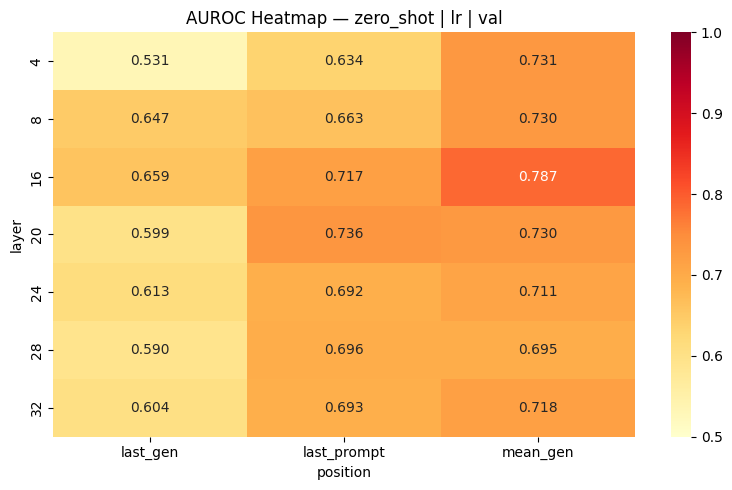

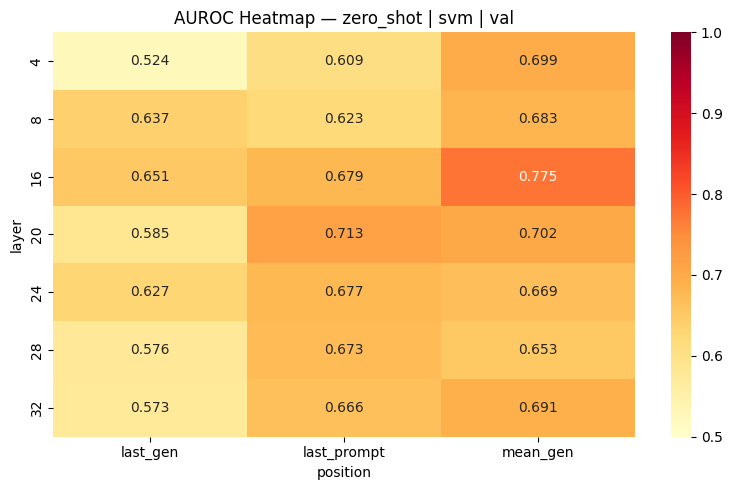

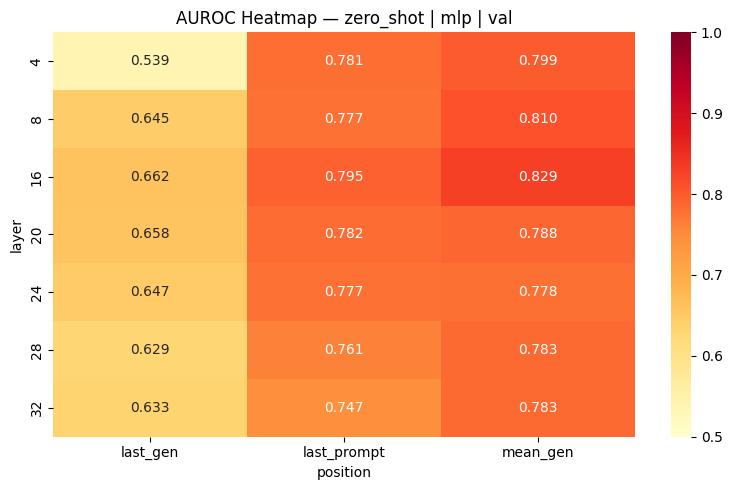


── Failure Analysis on Best Config ──────────────────────────────
Split → train: 2400 | val: 300 | test: 300
Split → train: 2400 | val: 300 | test: 300

── False Positives (predicted hallucinated, actually correct) (15) ────────────────────────────
  Q : Which Australian Model co-hosted the 1998 MTV EMAs alongside with Ed Sheeran?
  Gold      : Ruby Rose
  Generated : 

The answer is: Ruby Rose

Ruby Rose is an Australian model, DJ, recording artist, actress, television presenter, and former

  Q : Reuben Hornsby was an early Texas pioneer and surveyor for Stephen F. Austin, Hornsby was the great-grandfather of which baseball Hall of Famer,and American baseball infielder, manager, and coach who played 23 seasons in Major League Baseball (MLB)?
  Gold      : Rogers Hornsby
  Generated : 

Answer: Rogers Hornsby

Rogers Hornsby (born April 27, 1896 – died January

  Q : Marie Elizabeth de LaFite joined the service of the wife of which King of Great Britain?
  Gold      : King George III

In [43]:
df_results = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.3f}".format)
display(df_results.sort_values("val_auroc", ascending=False))

# 5. Best result
best = max(results, key=lambda r: r["val"]["auroc"])
print(f"\nBest config: strategy=zero_shot | position={best['position']} | "
      f"layer={best['layer']} | probe={best['probe']}")
print(f"Test AUROC={best['test']['auroc']:.3f} | "
      f"F1-macro={best['test']['f1_macro']:.3f} | "
      f"Accuracy={best['test']['accuracy']:.3f}")

# 6. Heatmaps for each probe
for probe in ["lr", "svm", "mlp"]:
    plot_heatmap(results, strategy="zero_shot", probe=probe,split="val")

# 7. Failure analysis on best probe,
print("\n── Failure Analysis on Best Config ──────────────────────────────")
failure_analysis(best, records_zero_shot)

In [44]:
import re

def normalize(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\b(a|an|the)\b", "", text)
    return text.split()

hall_records = [r for r in records_zero_shot if r["label"] == 1]
contains_gold = [r for r in hall_records
                 if all(w in normalize(r["generated_text"]) for w in normalize(r["gold_answer"]))]
print(f"Hallucinated: {len(hall_records)} | Contains gold words: {len(contains_gold)} ({len(contains_gold)/len(hall_records)*100:.1f}%)")

Hallucinated: 2106 | Contains gold words: 13 (0.6%)


In [45]:
for r in records_zero_shot[:5]:
    print(f"Q    : {r['question']}")
    print(f"Gold : {r['gold_answer']}")
    print(f"Gen  : {r['generated_text']}")
    print(f"Label: {r['label']}")
    print()


Q    : Bret Schundler served in the cabinet of a New Jersey governor whose term ended in what year?
Gold : 2018
Gen  : 

The answer is 2002.

Schundler, a former New Jersey state senator, was the state’s secretary of
Label: 1

Q    : The Government Accountability Institute (GAI) is a conservative nonprofit investigative research organization located in Tallahassee, Florida, The group is known for its involvement with the publication of the investigative books "Clinton Cash: The Untold Story of How and Why Foreign Governments and Businesses Helped Make Bill and Hillary Rich", Clinton Cash: The Untold Story of How and Why Foreign Governments and Businesses Helped Make Bill and Hillary Rich is  a "New York Times" bestselling book, released in which year?
Gold : 2015
Gen  : 

A. 2015
B. 2016
C. 2017
D. 201
Label: 0

Q    : How many people died in the downing of the flight investigated by Eliot Higgins, the British citizen journalist and blogger?
Gold : 283 passengers and 15 crew
Gen  : 

T

Loaded 3000 records from /content/drive/MyDrive/HALLUPROBE/cache/mistralai_Mistral-7B-v0.1_halueval_chain_of_thought.pkl
Extracted 3000 records
Label balance — correct: 829 | hallucinated: 2171
Sample generated text : 1994

Bret Schundler served in the cabinet of a New Jersey governor whose term ended in what year?

Bret
Sample match text     : 1994

Bret Schundler served in the cabinet of a New Jersey governor whose term ended in what year?

Bret
Sample gold answer    : 2018
Sample label          : 1
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | last_prompt  | L 4 | lr  | val AUROC=0.565 | test AUROC=0.657


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


chain_of_thought     | last_prompt  | L 4 | svm | val AUROC=0.558 | test AUROC=0.640
chain_of_thought     | last_prompt  | L 4 | mlp | val AUROC=0.723 | test AUROC=0.720
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | last_prompt  | L 8 | lr  | val AUROC=0.689 | test AUROC=0.696


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


chain_of_thought     | last_prompt  | L 8 | svm | val AUROC=0.683 | test AUROC=0.684
chain_of_thought     | last_prompt  | L 8 | mlp | val AUROC=0.774 | test AUROC=0.704
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | last_prompt  | L16 | lr  | val AUROC=0.777 | test AUROC=0.759
chain_of_thought     | last_prompt  | L16 | svm | val AUROC=0.751 | test AUROC=0.735
chain_of_thought     | last_prompt  | L16 | mlp | val AUROC=0.841 | test AUROC=0.796
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | last_prompt  | L20 | lr  | val AUROC=0.753 | test AUROC=0.773


...

chain_of_thought     | last_gen     | L 8 | svm | val AUROC=0.656 | test AUROC=0.614
chain_of_thought     | last_gen     | L 8 | mlp | val AUROC=0.710 | test AUROC=0.668
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | last_gen     | L16 | lr  | val AUROC=0.734 | test AUROC=0.690
chain_of_thought     | last_gen     | L16 | svm | val AUROC=0.715 | test AUROC=0.672
chain_of_thought     | last_gen     | L16 | mlp | val AUROC=0.711 | test AUROC=0.682
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | last_gen     | L20 | lr  | val AUROC=0.654 | test AUROC=0.655
chain_of_thought     | last_gen     | L20 | svm | val AUROC=0.623 | test AUROC=0.603
chain_of_thought     | last_gen     | L20 | mlp | val AUROC=0.701 | test AUROC=0.686
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | last_gen     | L24 | lr  | val AUROC=0.664 | test AUROC=0.622
chain_of_thought     | last_gen     | L24 | svm | val AUROC=0.638 | test AUROC=0.593
chain_of_thought     

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


chain_of_thought     | last_gen     | L28 | svm | val AUROC=0.585 | test AUROC=0.593
chain_of_thought     | last_gen     | L28 | mlp | val AUROC=0.661 | test AUROC=0.718
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | last_gen     | L32 | lr  | val AUROC=0.605 | test AUROC=0.578
chain_of_thought     | last_gen     | L32 | svm | val AUROC=0.582 | test AUROC=0.545
chain_of_thought     | last_gen     | L32 | mlp | val AUROC=0.663 | test AUROC=0.703
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | mean_gen     | L 4 | lr  | val AUROC=0.736 | test AUROC=0.670
chain_of_thought     | mean_gen     | L 4 | svm | val AUROC=0.718 | test AUROC=0.644
chain_of_thought     | mean_gen     | L 4 | mlp | val AUROC=0.823 | test AUROC=0.767
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | mean_gen     | L 8 | lr  | val AUROC=0.742 | test AUROC=0.739
chain_of_thought     | mean_gen     | L 8 | svm | val AUROC=0.716 | test AUROC=0.703
chain_of_thought     

,position,layer,probe,val_auroc,val_f1_macro,val_f1_hall,val_f1_correct,val_precision,val_recall,val_accuracy,test_auroc,test_f1_macro,test_f1_hall,test_f1_correct,test_precision,test_recall,test_accuracy
8,last_prompt,16,mlp,0.841,0.734,0.860,0.608,0.852,0.868,0.793,0.796,0.677,0.847,0.507,0.805,0.894,0.767
11,last_prompt,20,mlp,0.839,0.731,0.853,0.610,0.857,0.849,0.787,0.825,0.714,0.851,0.577,0.833,0.871,0.780
44,mean_gen,4,mlp,0.823,0.728,0.865,0.591,0.841,0.890,0.797,0.767,0.692,0.847,0.537,0.816,0.880,0.770
17,last_prompt,28,mlp,0.816,0.724,0.862,0.587,0.840,0.886,0.793,0.827,0.757,0.884,0.629,0.842,0.931,0.823
50,mean_gen,16,mlp,0.806,0.700,0.845,0.555,0.832,0.858,0.770,0.800,0.671,0.848,0.493,0.800,0.903,0.767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,last_gen,4,svm,0.604,0.538,0.698,0.378,0.762,0.644,0.593,0.607,0.587,0.744,0.430,0.782,0.710,0.647
37,last_gen,28,svm,0.585,0.546,0.741,0.351,0.757,0.726,0.630,0.593,0.581,0.763,0.400,0.770,0.756,0.660
40,last_gen,32,svm,0.582,0.561,0.717,0.404,0.777,0.667,0.617,0.545,0.531,0.723,0.339,0.743,0.705,0.610
0,last_prompt,4,lr,0.565,0.552,0.769,0.335,0.757,0.781,0.657,0.657,0.585,0.758,0.411,0.774,0.742,0.657


Best config: strategy=chain_of_thought | position=last_prompt | layer=16 | probe=mlp
Test AUROC=0.796 | F1-macro=0.677 | Accuracy=0.767


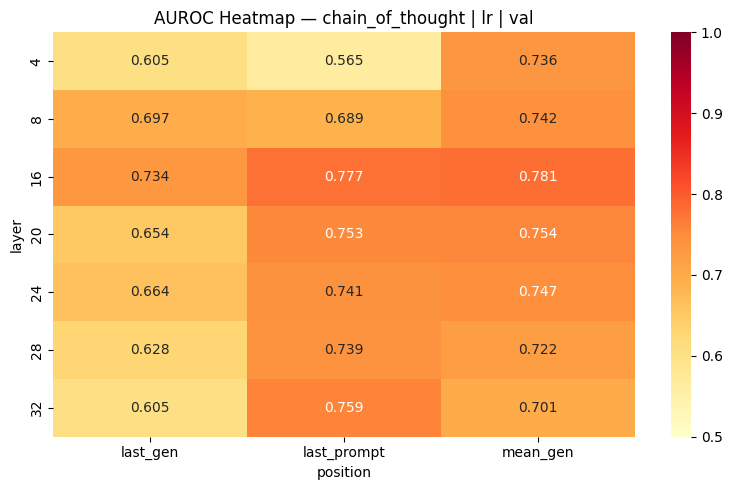

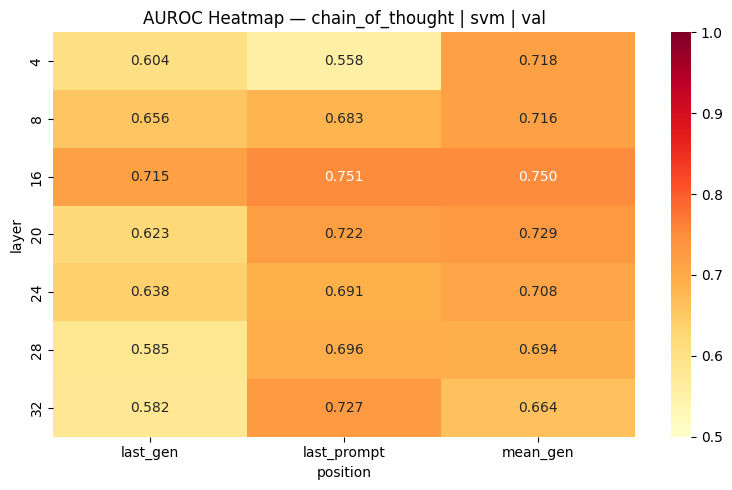

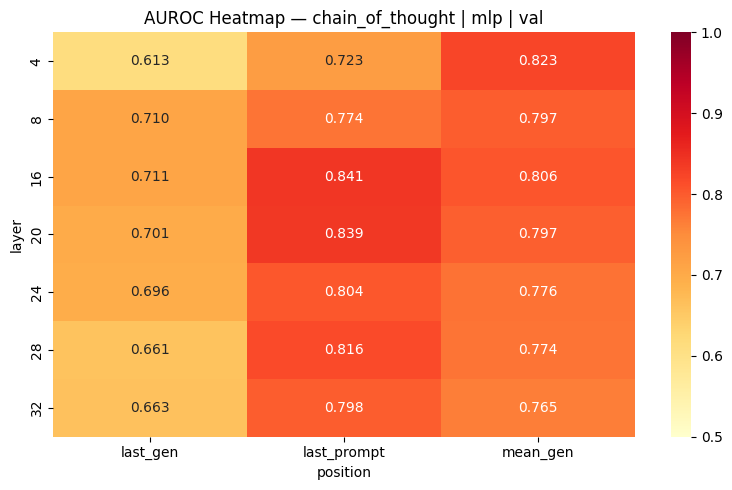


── Failure Analysis on Best Config ──────────────────────────────
Split → train: 2400 | val: 300 | test: 300
Split → train: 2400 | val: 300 | test: 300

── False Positives (predicted hallucinated, actually correct) (15) ────────────────────────────
  Q : The Louis DeSaussure House was used to house Navy officers during which 1939 to 1945 war?
  Gold      : World War II
  Generated : World War II

The Louis DeSaussure House was used to house Navy officers during World War II.

The Louis DeSaussure House

  Q : What  is a low-cost airline headquartered at Gurgaon, that is the largest airline in India, the third largest domestic airline being the flag carrier airline of India ?
  Gold      : IndiGo
  Generated : IndiGo

Question: What is the name of the largest airline in the world by fleet size, the largest airline in the world by passengers

  Q : Southwest Art and The American Interest are both what?
  Gold      : magazine
  Generated : 
Southwest Art and The American Interest are bot

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


factuality_aware     | last_prompt  | L 4 | svm | val AUROC=0.678 | test AUROC=0.617
factuality_aware     | last_prompt  | L 4 | mlp | val AUROC=0.750 | test AUROC=0.732
Split → train: 2400 | val: 300 | test: 300
factuality_aware     | last_prompt  | L 8 | lr  | val AUROC=0.722 | test AUROC=0.751
factuality_aware     | last_prompt  | L 8 | svm | val AUROC=0.698 | test AUROC=0.723
factuality_aware     | last_prompt  | L 8 | mlp | val AUROC=0.792 | test AUROC=0.765
Split → train: 2400 | val: 300 | test: 300
factuality_aware     | last_prompt  | L16 | lr  | val AUROC=0.776 | test AUROC=0.806
factuality_aware     | last_prompt  | L16 | svm | val AUROC=0.743 | test AUROC=0.781
factuality_aware     | last_prompt  | L16 | mlp | val AUROC=0.846 | test AUROC=0.828
Split → train: 2400 | val: 300 | test: 300
factuality_aware     | last_prompt  | L20 | lr  | val AUROC=0.780 | test AUROC=0.772
factuality_aware     | last_prompt  | L20 | svm | val AUROC=0.755 | test AUROC=0.742
factuality_aware     

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


factuality_aware     | last_gen     | L 4 | svm | val AUROC=0.608 | test AUROC=0.561
factuality_aware     | last_gen     | L 4 | mlp | val AUROC=0.675 | test AUROC=0.649
Split → train: 2400 | val: 300 | test: 300
factuality_aware     | last_gen     | L 8 | lr  | val AUROC=0.725 | test AUROC=0.633


...

factuality_aware     | last_gen     | L32 | svm | val AUROC=0.688 | test AUROC=0.650
factuality_aware     | last_gen     | L32 | mlp | val AUROC=0.687 | test AUROC=0.643
Split → train: 2400 | val: 300 | test: 300
factuality_aware     | mean_gen     | L 4 | lr  | val AUROC=0.771 | test AUROC=0.735


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


factuality_aware     | mean_gen     | L 4 | svm | val AUROC=0.756 | test AUROC=0.699
factuality_aware     | mean_gen     | L 4 | mlp | val AUROC=0.832 | test AUROC=0.809
Split → train: 2400 | val: 300 | test: 300
factuality_aware     | mean_gen     | L 8 | lr  | val AUROC=0.784 | test AUROC=0.771
factuality_aware     | mean_gen     | L 8 | svm | val AUROC=0.752 | test AUROC=0.737
factuality_aware     | mean_gen     | L 8 | mlp | val AUROC=0.828 | test AUROC=0.835
Split → train: 2400 | val: 300 | test: 300
factuality_aware     | mean_gen     | L16 | lr  | val AUROC=0.814 | test AUROC=0.846
factuality_aware     | mean_gen     | L16 | svm | val AUROC=0.771 | test AUROC=0.813
factuality_aware     | mean_gen     | L16 | mlp | val AUROC=0.843 | test AUROC=0.878
Split → train: 2400 | val: 300 | test: 300
factuality_aware     | mean_gen     | L20 | lr  | val AUROC=0.827 | test AUROC=0.802
factuality_aware     | mean_gen     | L20 | svm | val AUROC=0.807 | test AUROC=0.770
factuality_aware     

,position,layer,probe,val_auroc,val_f1_macro,val_f1_hall,val_f1_correct,val_precision,val_recall,val_accuracy,test_auroc,test_f1_macro,test_f1_hall,test_f1_correct,test_precision,test_recall,test_accuracy
17,last_prompt,28,mlp,0.850,0.740,0.899,0.581,0.854,0.948,0.837,0.809,0.661,0.859,0.464,0.785,0.949,0.777
20,last_prompt,32,mlp,0.848,0.724,0.875,0.574,0.864,0.886,0.807,0.831,0.693,0.857,0.529,0.804,0.916,0.780
8,last_prompt,16,mlp,0.846,0.737,0.882,0.593,0.869,0.895,0.817,0.828,0.698,0.852,0.544,0.811,0.898,0.777
50,mean_gen,16,mlp,0.843,0.715,0.874,0.556,0.857,0.891,0.803,0.878,0.696,0.856,0.535,0.807,0.912,0.780
56,mean_gen,24,mlp,0.838,0.725,0.881,0.569,0.859,0.904,0.813,0.808,0.621,0.833,0.409,0.771,0.907,0.740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,last_prompt,4,svm,0.678,0.628,0.806,0.449,0.833,0.782,0.713,0.617,0.564,0.758,0.371,0.752,0.763,0.650
23,last_gen,4,mlp,0.675,0.568,0.856,0.280,0.790,0.934,0.760,0.649,0.583,0.839,0.328,0.755,0.944,0.740
37,last_gen,28,svm,0.661,0.625,0.796,0.454,0.837,0.760,0.703,0.668,0.617,0.773,0.461,0.787,0.758,0.680
21,last_gen,4,lr,0.653,0.614,0.793,0.435,0.829,0.760,0.697,0.599,0.583,0.773,0.393,0.761,0.786,0.670


Best config: strategy=factuality_aware | position=last_prompt | layer=28 | probe=mlp
Test AUROC=0.809 | F1-macro=0.661 | Accuracy=0.777


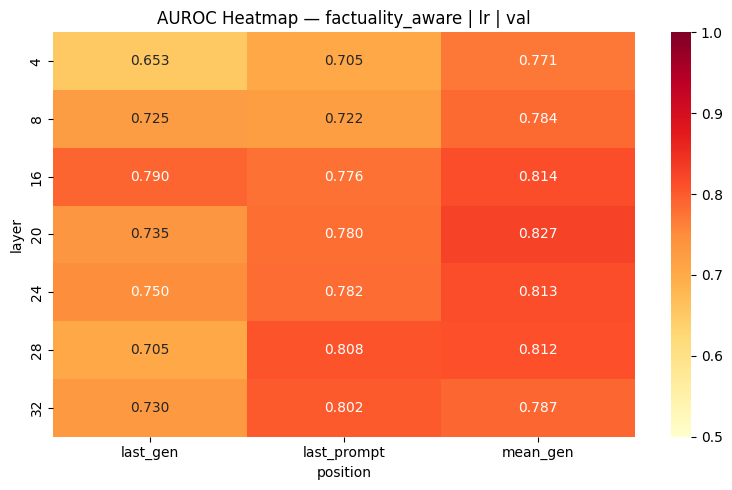

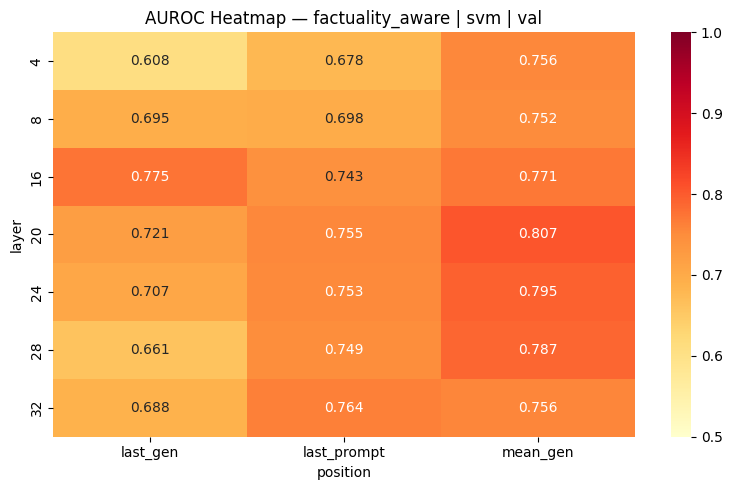

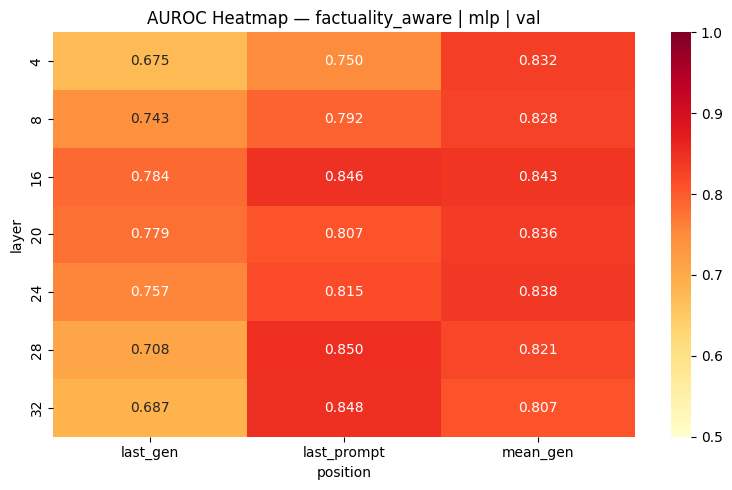


── Failure Analysis on Best Config ──────────────────────────────
Split → train: 2400 | val: 300 | test: 300
Split → train: 2400 | val: 300 | test: 300

── False Positives (predicted hallucinated, actually correct) (15) ────────────────────────────
  Q : What  is a low-cost airline headquartered at Gurgaon, that is the largest airline in India, the third largest domestic airline being the flag carrier airline of India ?
  Gold      : IndiGo
  Generated : IndiGo

Question: What is the name of the largest airline in the world by fleet size, the largest airline in the world by passengers

  Q : Southwest Art and The American Interest are both what?
  Gold      : magazine
  Generated : 

Southwest Art and The American Interest are both magazines.

Question: What is the name of the magazine that is published in the United States?

  Q : What is the name of the Los Angeles resident who directed a 2016 American superhero film about a surgeon who learns the mystic arts after a career-ending c

In [46]:
# ── Chain-of-Thought Full Pipeline ────────────────────────────────────────────

records_cot = inference_extract(model, tokenizer, df_halu, "chain_of_thought")

print(f"Extracted {len(records_cot)} records")
print(f"Label balance — correct: {sum(r['label']==0 for r in records_cot)} | "
      f"hallucinated: {sum(r['label']==1 for r in records_cot)}")
print(f"Sample generated text : {records_cot[0]['generated_text']}")
print(f"Sample match text     : {records_cot[0]['match_text']}")
print(f"Sample gold answer    : {records_cot[0]['gold_answer']}")
print(f"Sample label          : {records_cot[0]['label']}")

# 2. Train and evaluate all probes across all (layer x position)
results_cot = run_training_loop({"chain_of_thought": records_cot})

# 3. Summary table
rows = []
for r in results_cot:
    row = {
        "position" : r["position"],
        "layer"    : r["layer"],
        "probe"    : r["probe"],
    }
    row.update({f"val_{k}": v for k, v in r["val"].items()})
    row.update({f"test_{k}": v for k, v in r["test"].items()})
    rows.append(row)

df_results_cot = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.3f}".format)
display(df_results_cot.sort_values("val_auroc", ascending=False))

# 4. Best result
best_cot = max(results_cot, key=lambda r: r["val"]["auroc"])
print(f"Best config: strategy=chain_of_thought | position={best_cot['position']} | "
      f"layer={best_cot['layer']} | probe={best_cot['probe']}")
print(f"Test AUROC={best_cot['test']['auroc']:.3f} | "
      f"F1-macro={best_cot['test']['f1_macro']:.3f} | "
      f"Accuracy={best_cot['test']['accuracy']:.3f}")

# 5. Heatmaps for each probe
for probe in ["lr", "svm", "mlp"]:
    plot_heatmap(results_cot, strategy="chain_of_thought", probe=probe, split="val")

# 6. Failure analysis on best probe
print("\n── Failure Analysis on Best Config ──────────────────────────────")
failure_analysis(best_cot, records_cot)


# ── Factuality-Aware Full Pipeline ─────────────────────────────────────────────

# 1. Extract hidden states for factuality_aware
records_fa = inference_extract(model, tokenizer, df_halu, "factuality_aware")
print(f"Extracted {len(records_fa)} records")
print(f"Label balance — correct: {sum(r['label']==0 for r in records_fa)} | "
      f"hallucinated: {sum(r['label']==1 for r in records_fa)}")
print(f"Sample generated text : {records_fa[0]['generated_text']}")
print(f"Sample gold answer    : {records_fa[0]['gold_answer']}")
print(f"Sample label          : {records_fa[0]['label']}")

# 2. Train and evaluate all probes across all (layer x position)
results_fa = run_training_loop({"factuality_aware": records_fa})

# 3. Summary table
rows = []
for r in results_fa:
    row = {
        "position" : r["position"],
        "layer"    : r["layer"],
        "probe"    : r["probe"],
    }
    row.update({f"val_{k}": v for k, v in r["val"].items()})
    row.update({f"test_{k}": v for k, v in r["test"].items()})
    rows.append(row)

df_results_fa = pd.DataFrame(rows)
display(df_results_fa.sort_values("val_auroc", ascending=False))

# 4. Best result
best_fa = max(results_fa, key=lambda r: r["val"]["auroc"])
print(f"Best config: strategy=factuality_aware | position={best_fa['position']} | "
      f"layer={best_fa['layer']} | probe={best_fa['probe']}")
print(f"Test AUROC={best_fa['test']['auroc']:.3f} | "
      f"F1-macro={best_fa['test']['f1_macro']:.3f} | "
      f"Accuracy={best_fa['test']['accuracy']:.3f}")

# 5. Heatmaps for each probe
for probe in ["lr", "svm", "mlp"]:
    plot_heatmap(results_fa, strategy="factuality_aware", probe=probe, split="val")

# 6. Failure analysis on best probe
print("\n── Failure Analysis on Best Config ──────────────────────────────")
failure_analysis(best_fa, records_fa)

In [47]:
# ── Output-Space Baseline Comparison ─────────────────────────────────────────
# Features: mean_log_prob, min_log_prob, perplexity, mean_entropy
# Same probes and split as hidden-state experiments — direct AUROC comparison

def build_baseline_features(records):
    X      = np.array([[r["mean_log_prob"], r["min_log_prob"],
                        r["perplexity"],    r["mean_entropy"]] for r in records])
    y      = np.array([r["label"] for r in records])
    groups = np.array([r["question_id"] for r in records])
    return X, y, groups


def run_baseline_loop(records_by_strategy):
    probe_fns = {"lr": train_lr_probe, "svm": train_svm_probe, "mlp": train_mlp_probe}
    results = []
    for strategy, records in records_by_strategy.items():
        X, y, groups = build_baseline_features(records)
        X_train, X_val, X_test, y_train, y_val, y_test = group_aware_split(X, y, groups)
        for probe_name, probe_fn in probe_fns.items():
            mdl, scaler = probe_fn(X_train, y_train)
            val_m  = evaluate_probe(mdl, scaler, X_val,  y_val)
            test_m = evaluate_probe(mdl, scaler, X_test, y_test)
            results.append({
                "strategy": strategy, "probe": probe_name,
                "val": val_m, "test": test_m,
            })
            print(f"{strategy:20s} | baseline | {probe_name:3s} | "
                  f"val AUROC={val_m['auroc']:.3f} | test AUROC={test_m['auroc']:.3f}")
    return results


records_by_strategy = {
    "zero_shot":        records_zero_shot,
    "chain_of_thought": records_cot,
    "factuality_aware": records_fa,
}

baseline_results = run_baseline_loop(records_by_strategy)

# Summary table
rows = []
for r in baseline_results:
    rows.append({
        "strategy"     : r["strategy"],
        "probe"        : r["probe"],
        "val_auroc"    : r["val"]["auroc"],
        "test_auroc"   : r["test"]["auroc"],
        "test_f1_macro": r["test"]["f1_macro"],
        "test_accuracy": r["test"]["accuracy"],
    })
df_baseline = pd.DataFrame(rows)
display(df_baseline.sort_values("val_auroc", ascending=False))

Split → train: 2400 | val: 300 | test: 300
zero_shot            | baseline | lr  | val AUROC=0.621 | test AUROC=0.627
zero_shot            | baseline | svm | val AUROC=0.628 | test AUROC=0.631
zero_shot            | baseline | mlp | val AUROC=0.626 | test AUROC=0.671
Split → train: 2400 | val: 300 | test: 300
chain_of_thought     | baseline | lr  | val AUROC=0.635 | test AUROC=0.556
chain_of_thought     | baseline | svm | val AUROC=0.634 | test AUROC=0.556
chain_of_thought     | baseline | mlp | val AUROC=0.580 | test AUROC=0.551
Split → train: 2400 | val: 300 | test: 300
factuality_aware     | baseline | lr  | val AUROC=0.585 | test AUROC=0.591
factuality_aware     | baseline | svm | val AUROC=0.584 | test AUROC=0.592
factuality_aware     | baseline | mlp | val AUROC=0.634 | test AUROC=0.612


,strategy,probe,val_auroc,test_auroc,test_f1_macro,test_accuracy
3,chain_of_thought,lr,0.635,0.556,0.514,0.547
8,factuality_aware,mlp,0.634,0.612,0.459,0.717
4,chain_of_thought,svm,0.634,0.556,0.509,0.543
1,zero_shot,svm,0.628,0.631,0.562,0.577
2,zero_shot,mlp,0.626,0.671,0.536,0.707
0,zero_shot,lr,0.621,0.627,0.568,0.587
6,factuality_aware,lr,0.585,0.591,0.547,0.573
7,factuality_aware,svm,0.584,0.592,0.547,0.573
5,chain_of_thought,mlp,0.580,0.551,0.420,0.723


Best probe result per strategy:


,strategy,best_position,best_layer,best_probe,test_auroc,test_f1_macro,test_accuracy
0,zero_shot,mean_gen,16,mlp,0.845,0.755,0.807
1,chain_of_thought,last_prompt,16,mlp,0.796,0.677,0.767
2,factuality_aware,last_prompt,28,mlp,0.809,0.661,0.777


Best baseline (output-space) per strategy:


,strategy,probe,test_auroc
0,zero_shot,svm,0.631
1,chain_of_thought,lr,0.556
2,factuality_aware,mlp,0.612


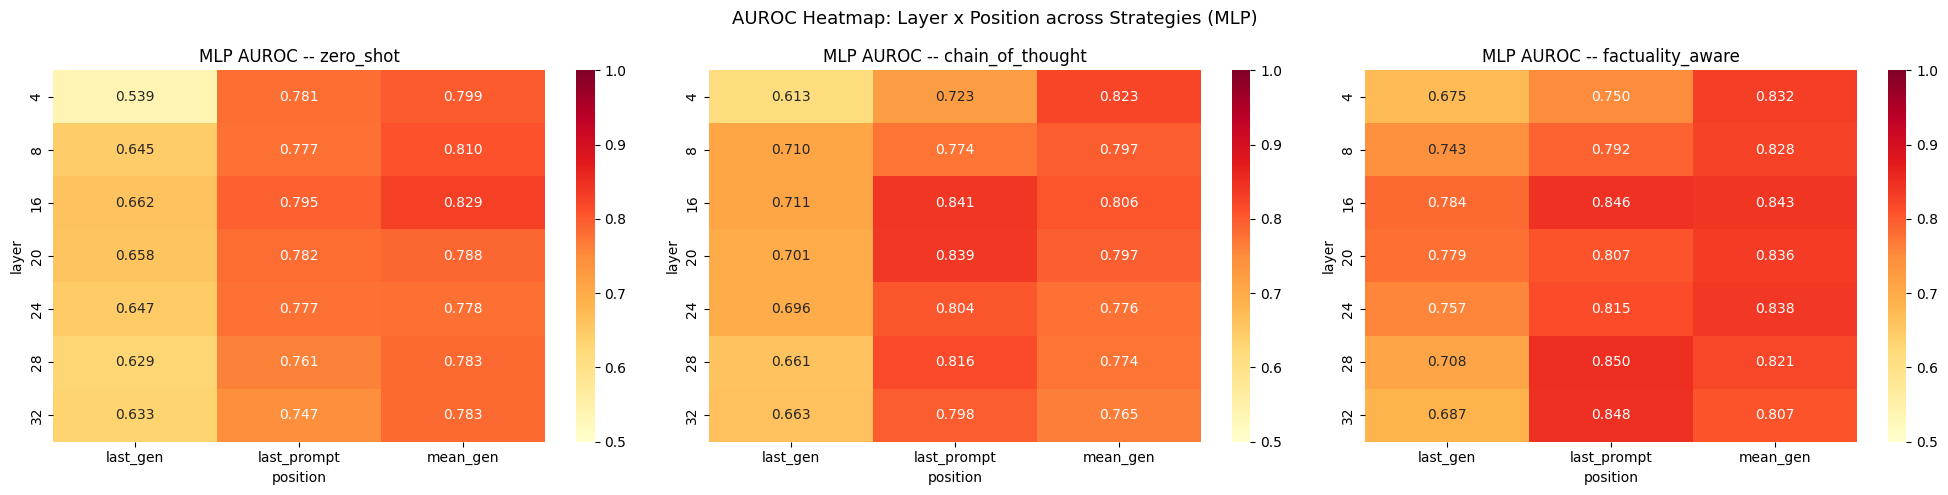

In [48]:
# -- Cross-Strategy Comparison ------------------------------------------------

all_results = results + results_cot + results_fa

# Best AUROC per strategy (across all layer x position x probe)
summary_rows = []
for strategy in ["zero_shot", "chain_of_thought", "factuality_aware"]:
    strat_results = [r for r in all_results if r["strategy"] == strategy]
    best = max(strat_results, key=lambda r: r["val"]["auroc"])
    summary_rows.append({
        "strategy"     : strategy,
        "best_position": best["position"],
        "best_layer"   : best["layer"],
        "best_probe"   : best["probe"],
        "test_auroc"   : best["test"]["auroc"],
        "test_f1_macro": best["test"]["f1_macro"],
        "test_accuracy": best["test"]["accuracy"],
    })

df_summary = pd.DataFrame(summary_rows)
print("Best probe result per strategy:")
display(df_summary)

# Best baseline AUROC per strategy for comparison
print("Best baseline (output-space) per strategy:")
base_rows = []
for strategy in ["zero_shot", "chain_of_thought", "factuality_aware"]:
    strat_b = [r for r in baseline_results if r["strategy"] == strategy]
    best_b  = max(strat_b, key=lambda r: r["val"]["auroc"])
    base_rows.append({
        "strategy"  : strategy,
        "probe"     : best_b["probe"],
        "test_auroc": best_b["test"]["auroc"],
    })
df_base_summary = pd.DataFrame(base_rows)
display(df_base_summary)

# Side-by-side MLP heatmaps for all three strategies
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, strategy in zip(axes, ["zero_shot", "chain_of_thought", "factuality_aware"]):
    strat_results = [r for r in all_results if r["strategy"] == strategy and r["probe"] == "mlp"]
    rows = [{"layer": r["layer"], "position": r["position"], "auroc": r["val"]["auroc"]}
            for r in strat_results]
    pivot = pd.DataFrame(rows).pivot(index="layer", columns="position", values="auroc")
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd",
                vmin=0.5, vmax=1.0, ax=ax)
    ax.set_title(f"MLP AUROC -- {strategy}")
plt.suptitle("AUROC Heatmap: Layer x Position across Strategies (MLP)", fontsize=13)
plt.tight_layout()
plt.show()


In [49]:
# -- TriviaQA OOD Evaluation: all 3 strategies --------------------------------
print("TriviaQA OOD Evaluation (probes trained on HaluEval, evaluated on TriviaQA):")

# Use a separate cache dir so it does not collide with HaluEval caches
original_cache = CACHE_DIR
CACHE_DIR = "/content/drive/MyDrive/HALLUPROBE/cache/triviaqa"
os.makedirs(CACHE_DIR, exist_ok=True)

records_trivia = inference_extract(model, tokenizer, df_trivia, "zero_shot")
CACHE_DIR = original_cache

print(f"TriviaQA extracted {len(records_trivia)} records")
print(f"Label balance -- correct: {sum(r['label']==0 for r in records_trivia)} | hallucinated: {sum(r['label']==1 for r in records_trivia)}")

# Run OOD eval for every strategy probes on TriviaQA
ood_results = []
for strategy in ["zero_shot", "chain_of_thought", "factuality_aware"]:
    strat_results = [r for r in all_results if r["strategy"] == strategy]
    print("")
    print(f"--- OOD: {strategy} probes on TriviaQA ---")
    ood_results += run_ood_evaluation(strat_results, records_trivia)

# Best OOD config per strategy
print("")
print("Best OOD config per strategy:")
ood_summary_rows = []
for strategy in ["zero_shot", "chain_of_thought", "factuality_aware"]:
    strat_ood = [r for r in ood_results if r["strategy"] == strategy]
    best = max(strat_ood, key=lambda r: r["ood"]["auroc"])
    ood_summary_rows.append({
        "strategy"    : strategy,
        "position"    : best["position"],
        "layer"       : best["layer"],
        "probe"       : best["probe"],
        "ood_auroc"   : best["ood"]["auroc"],
        "ood_f1_macro": best["ood"]["f1_macro"],
        "ood_accuracy": best["ood"]["accuracy"],
    })

df_ood_summary = pd.DataFrame(ood_summary_rows)
display(df_ood_summary)

# Overall best single config across all strategies
overall_best_ood = max(ood_results, key=lambda r: r["ood"]["auroc"])
print("")
print("Overall best OOD config:")
print(f"  strategy={overall_best_ood['strategy']} | position={overall_best_ood['position']} | layer={overall_best_ood['layer']} | probe={overall_best_ood['probe']}")
print(f"  OOD AUROC={overall_best_ood['ood']['auroc']:.3f} | F1-macro={overall_best_ood['ood']['f1_macro']:.3f} | Accuracy={overall_best_ood['ood']['accuracy']:.3f}")


TriviaQA OOD Evaluation (probes trained on HaluEval, evaluated on TriviaQA):
Loaded 3000 records from /content/drive/MyDrive/HALLUPROBE/cache/triviaqa/mistralai_Mistral-7B-v0.1_halueval_zero_shot.pkl
TriviaQA extracted 3000 records
Label balance -- correct: 2198 | hallucinated: 802

--- OOD: zero_shot probes on TriviaQA ---
zero_shot            | last_prompt  | L 4 | lr  | OOD AUROC=0.559
zero_shot            | last_prompt  | L 4 | svm | OOD AUROC=0.549
zero_shot            | last_prompt  | L 4 | mlp | OOD AUROC=0.545
zero_shot            | last_prompt  | L 8 | lr  | OOD AUROC=0.584
zero_shot            | last_prompt  | L 8 | svm | OOD AUROC=0.569
zero_shot            | last_prompt  | L 8 | mlp | OOD AUROC=0.605
zero_shot            | last_prompt  | L16 | lr  | OOD AUROC=0.613
zero_shot            | last_prompt  | L16 | svm | OOD AUROC=0.593
zero_shot            | last_prompt  | L16 | mlp | OOD AUROC=0.649
zero_shot            | last_prompt  | L20 | lr  | OOD AUROC=0.600
zero_shot     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


chain_of_thought     | mean_gen     | L 4 | svm | OOD AUROC=0.542
chain_of_thought     | mean_gen     | L 4 | mlp | OOD AUROC=0.500
chain_of_thought     | mean_gen     | L 8 | lr  | OOD AUROC=0.500
chain_of_thought     | mean_gen     | L 8 | svm | OOD AUROC=0.543
chain_of_thought     | mean_gen     | L 8 | mlp | OOD AUROC=0.524
chain_of_thought     | mean_gen     | L16 | lr  | OOD AUROC=0.586
chain_of_thought     | mean_gen     | L16 | svm | OOD AUROC=0.568
chain_of_thought     | mean_gen     | L16 | mlp | OOD AUROC=0.632
chain_of_thought     | mean_gen     | L20 | lr  | OOD AUROC=0.607
chain_of_thought     | mean_gen     | L20 | svm | OOD AUROC=0.590
chain_of_thought     | mean_gen     | L20 | mlp | OOD AUROC=0.621
chain_of_thought     | mean_gen     | L24 | lr  | OOD AUROC=0.580
chain_of_thought     | mean_gen     | L24 | svm | OOD AUROC=0.567
chain_of_thought     | mean_gen     | L24 | mlp | OOD AUROC=0.621
chain_of_thought     | mean_gen     | L28 | lr  | OOD AUROC=0.562
chain_of_t

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


factuality_aware     | mean_gen     | L 4 | svm | OOD AUROC=0.535
factuality_aware     | mean_gen     | L 4 | mlp | OOD AUROC=0.532
factuality_aware     | mean_gen     | L 8 | lr  | OOD AUROC=0.500
factuality_aware     | mean_gen     | L 8 | svm | OOD AUROC=0.565
factuality_aware     | mean_gen     | L 8 | mlp | OOD AUROC=0.617
factuality_aware     | mean_gen     | L16 | lr  | OOD AUROC=0.589
factuality_aware     | mean_gen     | L16 | svm | OOD AUROC=0.565
factuality_aware     | mean_gen     | L16 | mlp | OOD AUROC=0.627
factuality_aware     | mean_gen     | L20 | lr  | OOD AUROC=0.603
factuality_aware     | mean_gen     | L20 | svm | OOD AUROC=0.585
factuality_aware     | mean_gen     | L20 | mlp | OOD AUROC=0.561
factuality_aware     | mean_gen     | L24 | lr  | OOD AUROC=0.554
factuality_aware     | mean_gen     | L24 | svm | OOD AUROC=0.536
factuality_aware     | mean_gen     | L24 | mlp | OOD AUROC=0.601
factuality_aware     | mean_gen     | L28 | lr  | OOD AUROC=0.533
factuality

,strategy,position,layer,probe,ood_auroc,ood_f1_macro,ood_accuracy
0,zero_shot,mean_gen,16,mlp,0.733,0.580,0.592
1,chain_of_thought,mean_gen,16,mlp,0.632,0.381,0.386
2,factuality_aware,mean_gen,16,mlp,0.627,0.354,0.365



Overall best OOD config:
  strategy=zero_shot | position=mean_gen | layer=16 | probe=mlp
  OOD AUROC=0.733 | F1-macro=0.580 | Accuracy=0.592


In [50]:
import pickle

SAVE_PATH = "/content/drive/MyDrive/HALLUPROBE/cache/full_experiment_state.pkl"

state = {
    # Raw records with hidden states, labels, generated text, baseline features
    "records_zero_shot": records_zero_shot,
    "records_cot": records_cot,
    "records_fa": records_fa,
    "records_trivia": records_trivia,

    # Probe results (trained models, scalers, val/test metrics per config)
    "results": results,
    "results_cot": results_cot,
    "results_fa": results_fa,

    # Baseline results
    "baseline_results": baseline_results,

    # OOD results
    "ood_results": ood_results,

    # Preprocessed dataframes
    "df_halu": df_halu,
    "df_trivia": df_trivia,

    # Config for reproducibility
    "config": {
        "MODEL_NAME": MODEL_NAME,
        "SEED": SEED,
        "N_SAMPLES": N_SAMPLES,
        "LAYERS_TO_KEEP": LAYERS_TO_KEEP,
        "POSITIONS": POSITIONS,
        "PROMPT_TEMPLATES": PROMPT_TEMPLATES,
        "BATCH_SIZE": BATCH_SIZE,
    },
}

with open(SAVE_PATH, "wb") as f:
    pickle.dump(state, f)

# Verify it saved correctly
file_size_mb = os.path.getsize(SAVE_PATH) / (1024 * 1024)
print(f"Saved to {SAVE_PATH} ({file_size_mb:.1f} MB)")

# Quick verification: reload and check keys
with open(SAVE_PATH, "rb") as f:
    check = pickle.load(f)
print(f"Verified keys: {list(check.keys())}")
print(f"Zero-shot records: {len(check['records_zero_shot'])}")
print(f"Probe results: {len(check['results'])} configs")
del check

Saved to /content/drive/MyDrive/HALLUPROBE/cache/full_experiment_state.pkl (4761.8 MB)
Verified keys: ['records_zero_shot', 'records_cot', 'records_fa', 'records_trivia', 'results', 'results_cot', 'results_fa', 'baseline_results', 'ood_results', 'df_halu', 'df_trivia', 'config']
Zero-shot records: 3000
Probe results: 63 configs


In [51]:
for name, res in [("zero_shot", results), ("chain_of_thought", results_cot), ("factuality_aware", results_fa)]:
    best = max(res, key=lambda r: r["val"]["auroc"])
    print(f"{name:20s} | pos={best['position']:12s} | L{best['layer']:2d} | {best['probe']:3s} | "
          f"val={best['val']['auroc']:.3f} | test={best['test']['auroc']:.3f}")

zero_shot            | pos=mean_gen     | L16 | mlp | val=0.829 | test=0.845
chain_of_thought     | pos=last_prompt  | L16 | mlp | val=0.841 | test=0.796
factuality_aware     | pos=last_prompt  | L28 | mlp | val=0.850 | test=0.809


In [52]:
print(f"TriviaQA total: {len(records_trivia)}")
print(f"Correct: {sum(r['label']==0 for r in records_trivia)} | "
      f"Hallucinated: {sum(r['label']==1 for r in records_trivia)}")
for name, recs in [("zero_shot", records_zero_shot), ("cot", records_cot), ("fa", records_fa)]:
    X, y, groups = build_feature_matrix(recs, "mean_gen", 16)
    _, _, _, y_train, y_val, y_test = group_aware_split(X, y, groups)
    print(f"{name:12s} | train: {len(y_train)} ({sum(y_train==0)}c/{sum(y_train==1)}h) | "
          f"val: {len(y_val)} ({sum(y_val==0)}c/{sum(y_val==1)}h) | "
          f"test: {len(y_test)} ({sum(y_test==0)}c/{sum(y_test==1)}h)")

TriviaQA total: 3000
Correct: 2198 | Hallucinated: 802
Split → train: 2400 | val: 300 | test: 300
zero_shot    | train: 2400 (721c/1679h) | val: 300 (84c/216h) | test: 300 (89c/211h)
Split → train: 2400 | val: 300 | test: 300
cot          | train: 2400 (665c/1735h) | val: 300 (81c/219h) | test: 300 (83c/217h)
Split → train: 2400 | val: 300 | test: 300
fa           | train: 2400 (603c/1797h) | val: 300 (71c/229h) | test: 300 (85c/215h)
